Succesful data from the first draft homemade fiber bunny with 108kHz piezo. In one drive, folder is called "Vertical_vibration_piezo_fiber_bunny", and the date is 20250929.

In [26]:
import sys
import os
import glob
sys.path.append("../")
import analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

# Base path to data
base_path = r"C:\Users\sl57562\The University of Texas at Austin\Acoustic + Calcium - Documents\Acoustic\Vertical_vibration_piezo_fiber_bunny\20250929\20250929"

# Extract all unique power levels from folder names
folders = os.listdir(base_path)
power_levels = set()

for folder in folders:
    if "power_scan" in folder:
        # Extract power level from folder name
        parts = folder.split("_")
        for part in parts:
            if "mW" in part and "noise" not in part:
                # Extract the number from something like "30mW"
                power_level = int(part.replace("mW", ""))
                power_levels.add(power_level)

power_levels = sorted(list(power_levels))
print(f"Found {len(power_levels)} power levels: {power_levels}")

Found 15 power levels: [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 105, 110, 120, 125]


In [27]:
# Initialize storage for SNR results
snr_results = {}

# Process each power level
for power_level in power_levels:
    print(f"\n{'='*60}")
    print(f"Processing power level: {power_level} mW")
    print(f"{'='*60}")
    
    # Construct folder names
    signal_folder = f"power_scan_108kHz_10V_{power_level}mW"
    noise_folder = f"power_scan_108kHz_10V_{power_level}mW_noise"
    
    signal_path = os.path.join(base_path, signal_folder)
    noise_path = os.path.join(base_path, noise_folder)
    
    # Check if folders exist
    if not os.path.exists(signal_path):
        print(f"Signal folder not found: {signal_path}")
        continue
    if not os.path.exists(noise_path):
        print(f"Noise folder not found: {noise_path}")
        continue
    
    # Build file lists
    signal_files = [os.path.join(signal_path, f"iter_{x}.tdms") for x in range(19)]
    noise_files = [os.path.join(noise_path, f"iter_{x}.tdms") for x in range(19)]
    
    # Verify files exist
    signal_files = [f for f in signal_files if os.path.exists(f)]
    noise_files = [f for f in noise_files if os.path.exists(f)]
    
    print(f"Signal files: {len(signal_files)}, Noise files: {len(noise_files)}")
    
    if len(signal_files) == 0 or len(noise_files) == 0:
        print(f"Skipping {power_level} mW: insufficient files")
        continue
    
    # Load data
    try:
        system = analysis.System(
            f"power_{power_level}mW",
            signal_files + noise_files,
            channel="X",
            set_data=True
        )
    except Exception as e:
        print(f"Error loading data: {e}")
        continue
    
    print(f"Loaded {len(system.get_data())} total collections")


Processing power level: 1 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 10 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 20 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 30 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 40 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 50 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 60 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 70 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 80 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 90 mW
Signal files: 19, Noise files: 19
Loaded 38 total collections

Processing power level: 100 mW
Signal files: 19, Noise files: 19
Loade

In [49]:
# Process each power level and compute SNR using Welch's method
from scipy.signal import welch

snr_results = {}

for power_level in power_levels:
    print(f"\nProcessing {power_level} mW...")
    
    # Construct folder names
    signal_folder = f"power_scan_108kHz_10V_{power_level}mW"
    noise_folder = f"power_scan_108kHz_10V_{power_level}mW_noise"
    
    signal_path = os.path.join(base_path, signal_folder)
    noise_path = os.path.join(base_path, noise_folder)
    
    # Check if folders exist
    if not os.path.exists(signal_path) or not os.path.exists(noise_path):
        print(f"  Skipping: folders not found")
        continue
    
    # Build file lists
    signal_files = [os.path.join(signal_path, f"iter_{x}.tdms") for x in range(19)]
    noise_files = [os.path.join(noise_path, f"iter_{x}.tdms") for x in range(19)]
    
    # Verify files exist
    signal_files = [f for f in signal_files if os.path.exists(f)]
    noise_files = [f for f in noise_files if os.path.exists(f)]
    
    if len(signal_files) < 5 or len(noise_files) < 5:
        print(f"  Skipping: insufficient files")
        continue
    
    # Load data
    try:
        system = analysis.System(
            f"power_{power_level}mW",
            signal_files + noise_files,
            channel="X",
            set_data=True
        )
    except Exception as e:
        print(f"  Error loading data: {e}")
        continue
    
    # Compute PSD for all collections using Welch's method
    freqs = np.array([])
    psds = np.array([])
    
    for i, d in enumerate(system.get_data()):
        d.apply("detrend", mode="linear", inplace=True)
        
        for j, c in enumerate(d.collection):
            f, x = welch(c.x, system.get_data()[i].r, nfft=2**15, nperseg=2**14)
            
            if i == 0 and j == 0:
                freqs = np.append(freqs, f)
                psds = np.append(psds, x)
            else:
                freqs = np.vstack((freqs, f)) if freqs.ndim > 1 else np.vstack((freqs, f))
                psds = np.vstack((psds, x)) if psds.ndim > 1 else np.vstack((psds, x))
        
        system.set_data(ind=i)
    
    # Separate signal and noise PSDs
    num_signal = len(signal_files) * 2  # 2 collections per file
    num_noise = len(noise_files) * 2
    
    avg_freqs = np.mean(freqs, axis=0)
    avg_signal_psd = np.mean(psds[:num_signal], axis=0)
    avg_noise_psd = np.mean(psds[num_signal:], axis=0)
    cleaned_signal = np.maximum(avg_signal_psd - avg_noise_psd, 10e-20)
    
    # Find indices for 108-109 kHz band
    band_min_idx = np.searchsorted(avg_freqs, 108e3)
    band_max_idx = np.searchsorted(avg_freqs, 109e3)
    
    # Calculate wideband SNR: signal PSD vs noise PSD
    wideband_signal_power = np.trapezoid(cleaned_signal, avg_freqs)
    wideband_noise_power = np.trapezoid(cleaned_signal, avg_freqs)
    snr_wideband = 10 * np.log10(wideband_signal_power / wideband_noise_power)
    
    # Calculate in-band SNR: signal PSD vs noise PSD in 108-109 kHz band
    inband_signal_power = np.trapezoid(cleaned_signal[band_min_idx:band_max_idx], avg_freqs[band_min_idx:band_max_idx])
    inband_noise_power = np.trapezoid(cleaned_signal[band_min_idx:band_max_idx], avg_freqs[band_min_idx:band_max_idx])
    snr_inband = 10 * np.log10(inband_signal_power / inband_noise_power)
    
    snr_results[power_level] = {
        "freqs": avg_freqs,
        "signal": cleaned_signal,
        "noise": avg_noise_psd,
        "snr_wideband": snr_wideband,
        "snr_inband": snr_inband,
        "band_min_idx": band_min_idx,
        "band_max_idx": band_max_idx
    }
    
    print(f"  SNR (wideband):  {snr_wideband:.2f} dB")
    print(f"  SNR (in-band):   {snr_inband:.2f} dB")


Processing 1 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 10 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 20 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 30 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 40 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 50 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 60 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 70 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 80 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 90 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 100 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 105 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 110 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.00 dB

Processing 120 mW...
 

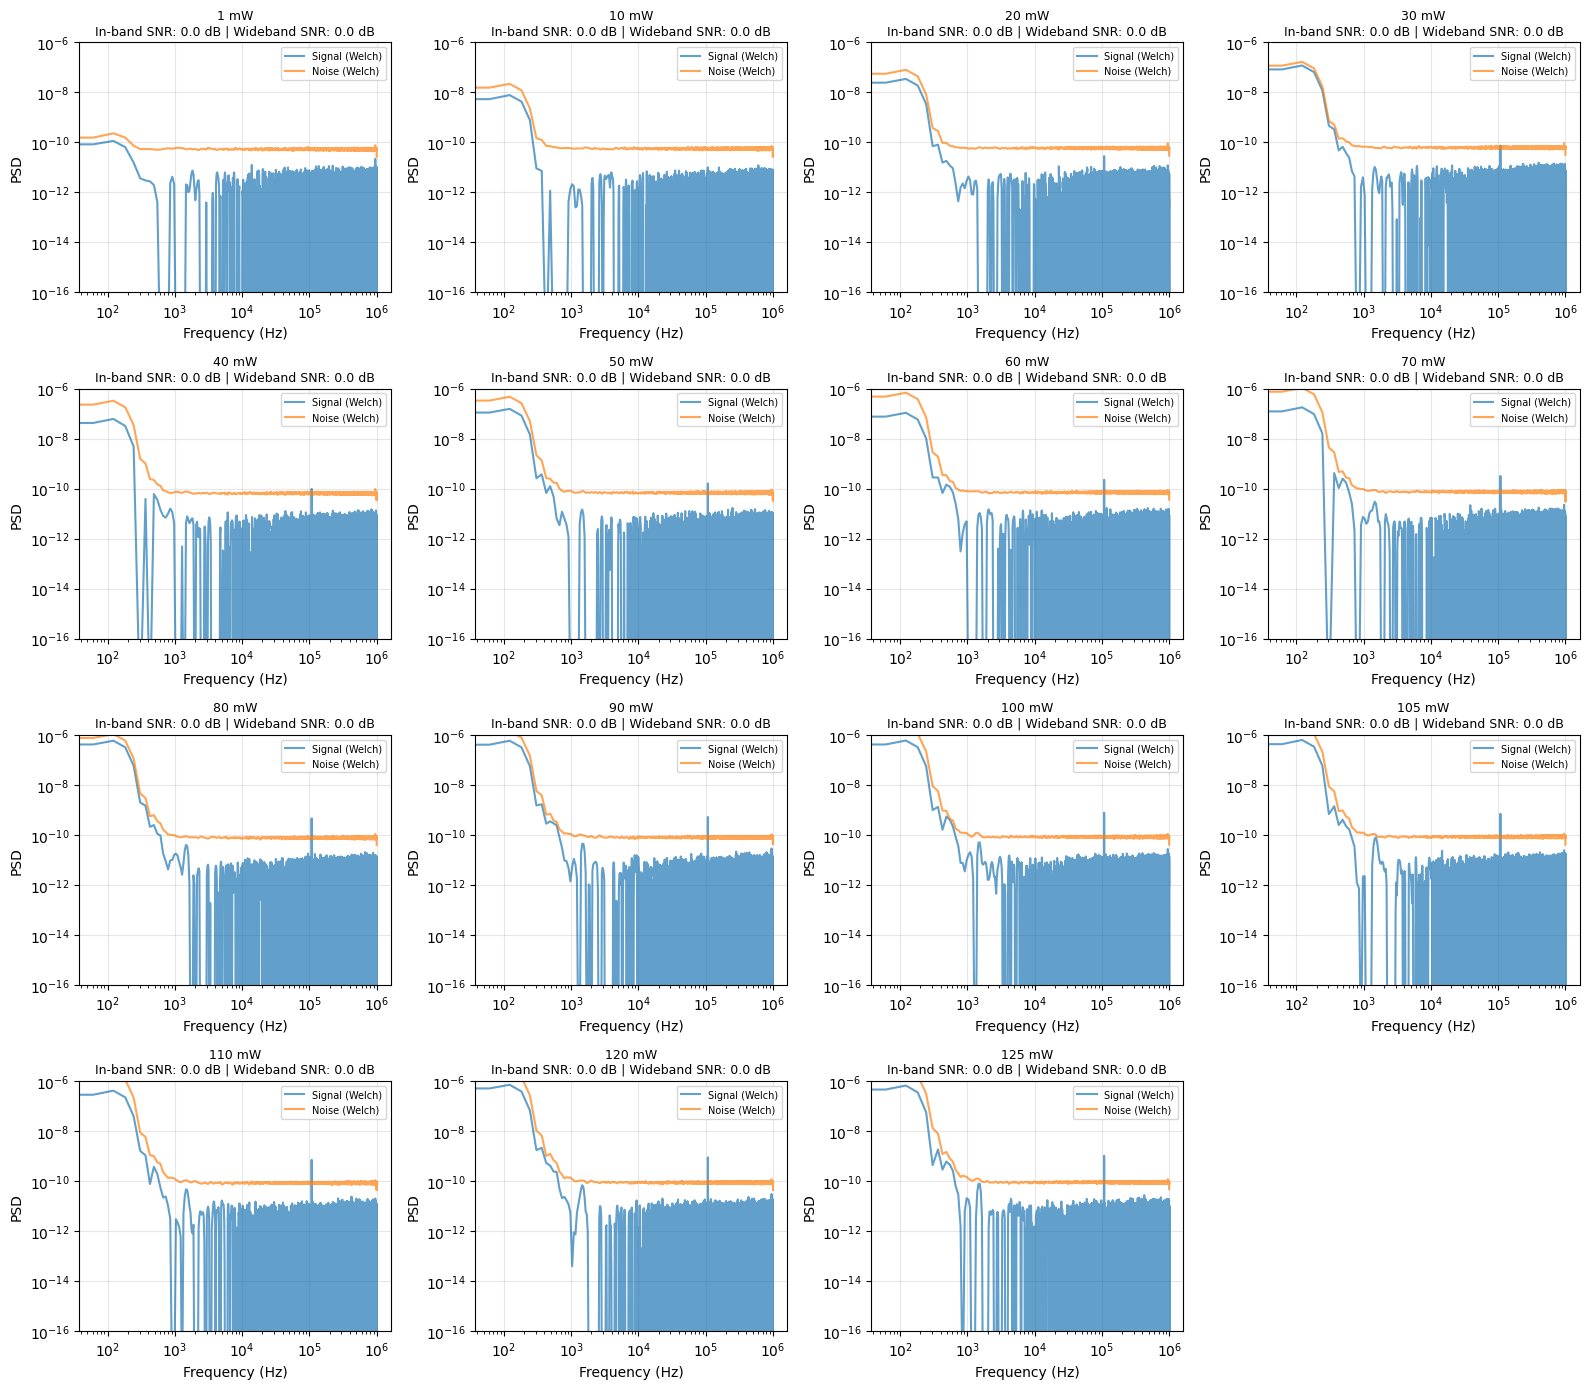

In [50]:
# Plot PSD for each power level
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, (power_level, results) in enumerate(sorted(snr_results.items())):
    ax = axes[idx]
    ax.loglog(results["freqs"], results["signal"], label="Signal (Welch)", alpha=0.7)
    ax.loglog(results["freqs"], results["noise"], label="Noise (Welch)", alpha=0.7)
    
    ax.set_title(f"{power_level} mW\nIn-band SNR: {results['snr_inband']:.1f} dB | Wideband SNR: {results['snr_wideband']:.1f} dB", fontsize=9)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(1e-16, 1e-6)

# Hide unused subplots
for idx in range(len(snr_results), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

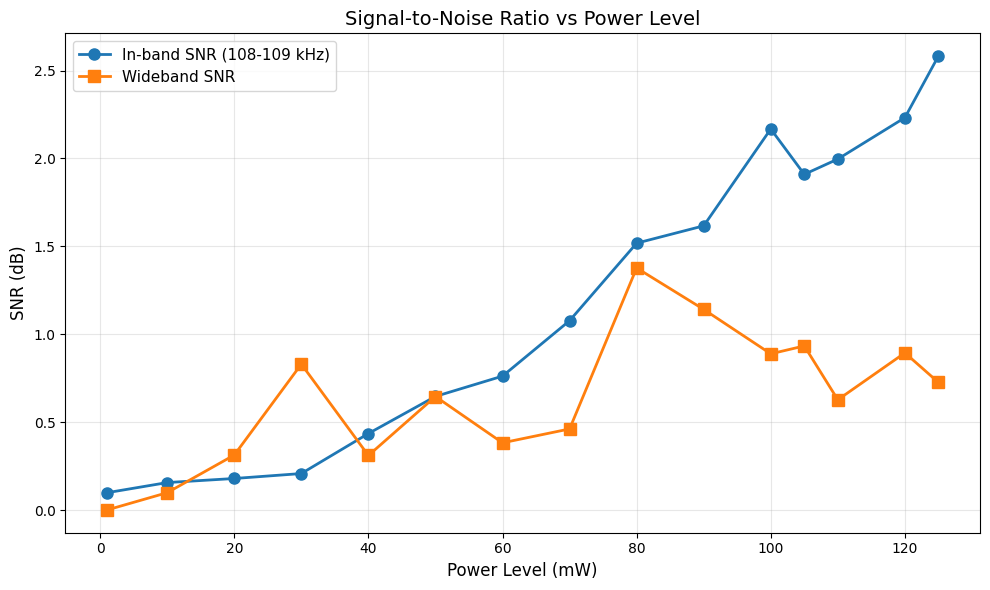


Power (mW)      In-band SNR (108-109 kHz) (dB)      Wideband SNR (dB)             
1.0             0.10                                0.00                          
10.0            0.16                                0.10                          
20.0            0.18                                0.31                          
30.0            0.21                                0.83                          
40.0            0.44                                0.31                          
50.0            0.65                                0.65                          
60.0            0.76                                0.38                          
70.0            1.08                                0.46                          
80.0            1.52                                1.38                          
90.0            1.62                                1.14                          
100.0           2.17                                0.89                          
105

In [53]:
# Plot SNR vs Power Level
power_levels_sorted = sorted(snr_results.keys())
snr_inband = [snr_results[p]["snr_inband"] for p in power_levels_sorted]
snr_wideband = [snr_results[p]["snr_wideband"] for p in power_levels_sorted]

plt.figure(figsize=(10, 6))
plt.plot(power_levels_sorted, snr_inband, 'o-', label="In-band SNR (108-109 kHz)", linewidth=2, markersize=8)
plt.plot(power_levels_sorted, snr_wideband, 's-', label="Wideband SNR", linewidth=2, markersize=8)
plt.xlabel("Power Level (mW)", fontsize=12)
plt.ylabel("SNR (dB)", fontsize=12)
plt.title("Signal-to-Noise Ratio vs Power Level", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print(f"{'Power (mW)':<15} {'In-band SNR (108-109 kHz) (dB)':<35} {'Wideband SNR (dB)':<30}")
print("="*80)
for p in power_levels_sorted:
    print(f"{p:<15.1f} {snr_results[p]['snr_inband']:<35.2f} {snr_results[p]['snr_wideband']:<30.2f}")
print("="*80)


Processing 1 mW...
  SNR (wideband):  0.00 dB
  SNR (in-band):   0.10 dB

Processing 10 mW...
  SNR (wideband):  0.10 dB
  SNR (in-band):   0.16 dB

Processing 20 mW...
  SNR (wideband):  0.31 dB
  SNR (in-band):   0.18 dB

Processing 30 mW...
  SNR (wideband):  0.83 dB
  SNR (in-band):   0.21 dB

Processing 40 mW...
  SNR (wideband):  0.31 dB
  SNR (in-band):   0.44 dB

Processing 50 mW...
  SNR (wideband):  0.65 dB
  SNR (in-band):   0.65 dB

Processing 60 mW...
  SNR (wideband):  0.38 dB
  SNR (in-band):   0.76 dB

Processing 70 mW...
  SNR (wideband):  0.46 dB
  SNR (in-band):   1.08 dB

Processing 80 mW...
  SNR (wideband):  1.38 dB
  SNR (in-band):   1.52 dB

Processing 90 mW...
  SNR (wideband):  1.14 dB
  SNR (in-band):   1.62 dB

Processing 100 mW...
  SNR (wideband):  0.89 dB
  SNR (in-band):   2.17 dB

Processing 105 mW...
  SNR (wideband):  0.93 dB
  SNR (in-band):   1.91 dB

Processing 110 mW...
  SNR (wideband):  0.63 dB
  SNR (in-band):   2.00 dB

Processing 120 mW...
 

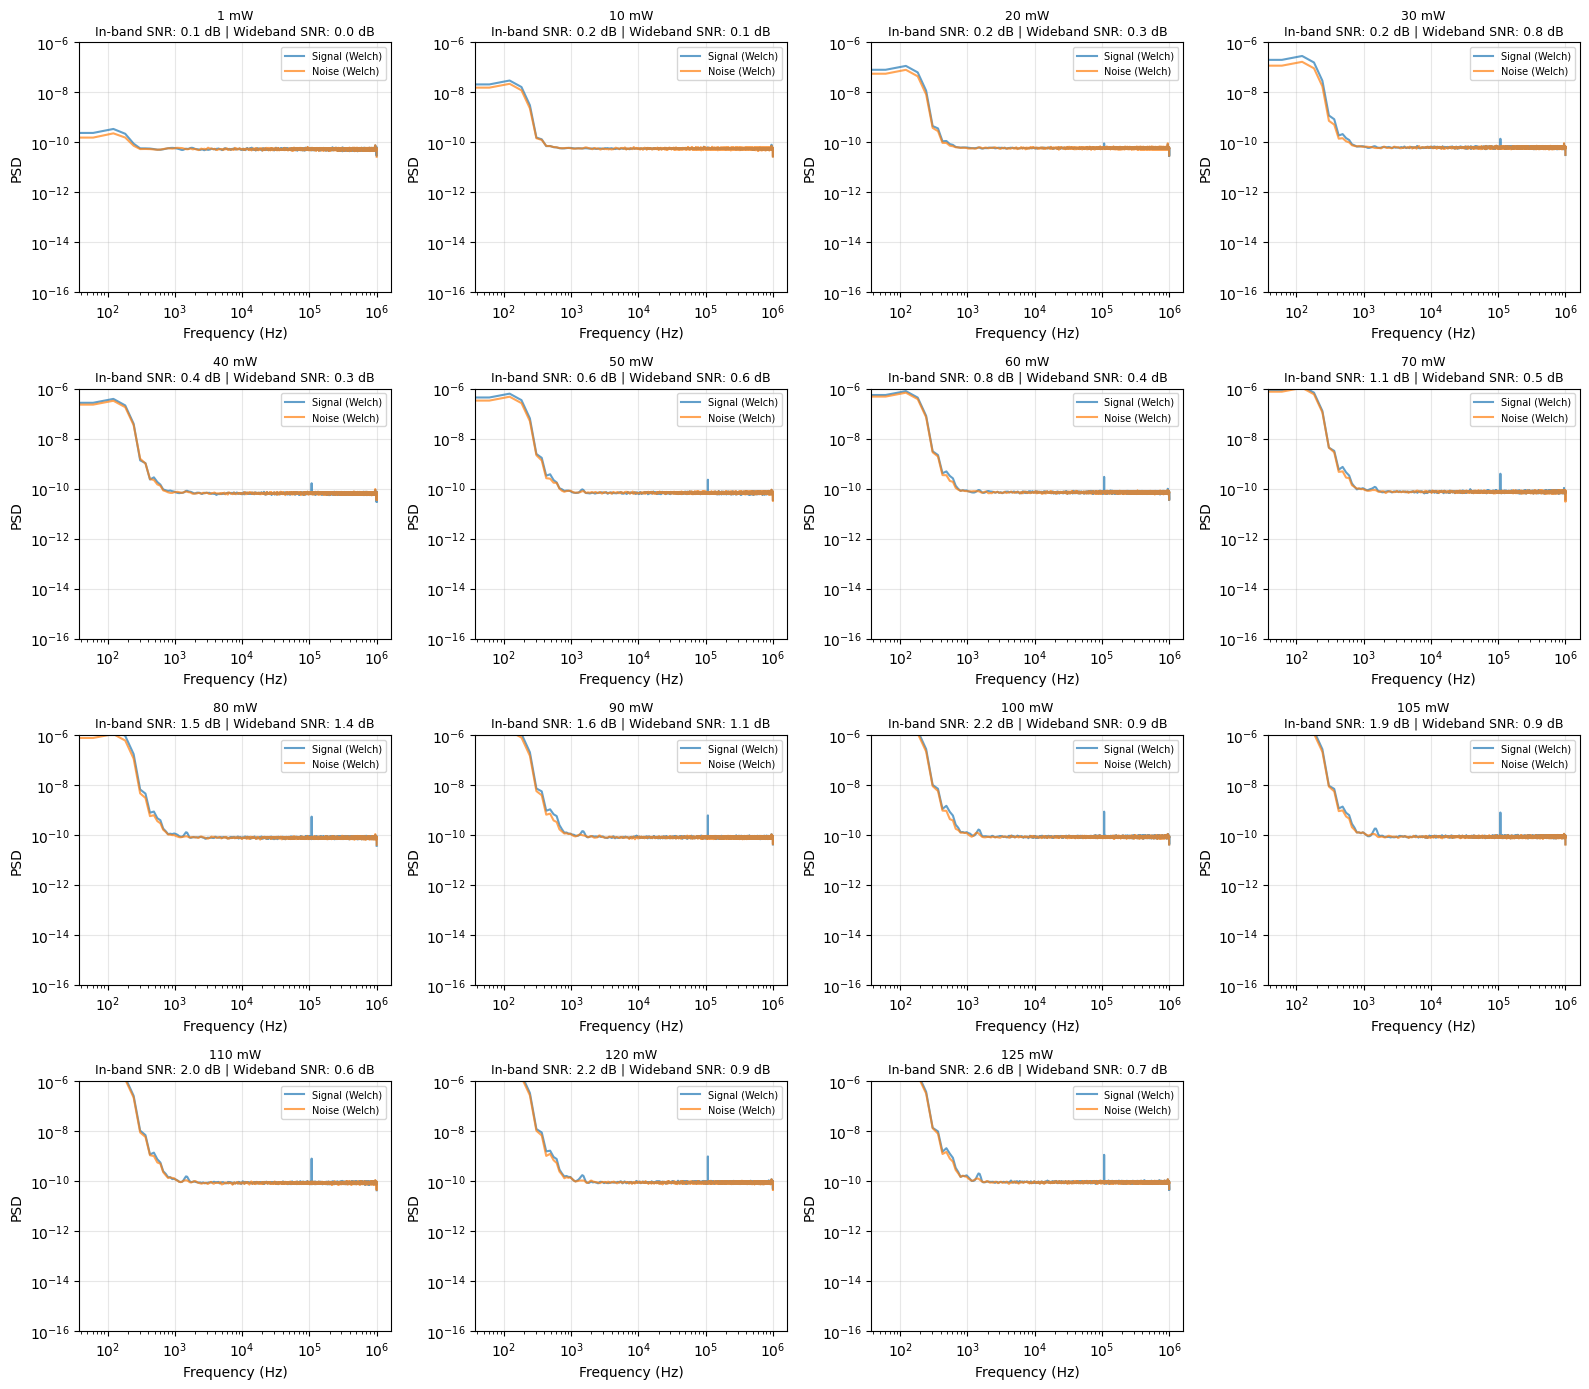

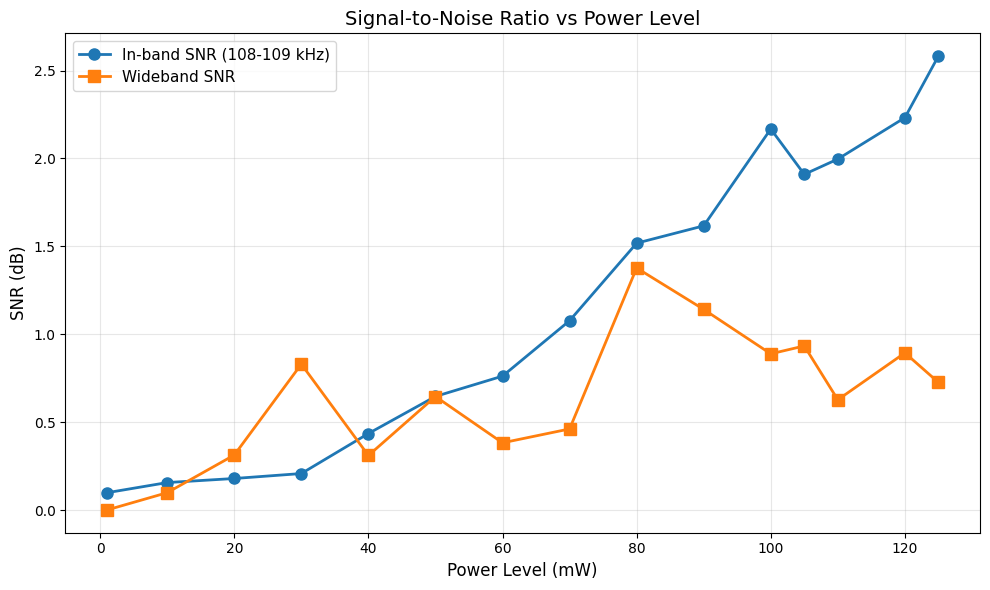

In [51]:
# comparing processing techniques ----- welch

# Process each power level and compute SNR using Welch's method
from scipy.signal import welch

snr_results = {}

for power_level in power_levels:
    print(f"\nProcessing {power_level} mW...")
    
    # Construct folder names
    signal_folder = f"power_scan_108kHz_10V_{power_level}mW"
    noise_folder = f"power_scan_108kHz_10V_{power_level}mW_noise"
    
    signal_path = os.path.join(base_path, signal_folder)
    noise_path = os.path.join(base_path, noise_folder)
    
    # Check if folders exist
    if not os.path.exists(signal_path) or not os.path.exists(noise_path):
        print(f"  Skipping: folders not found")
        continue
    
    # Build file lists
    signal_files = [os.path.join(signal_path, f"iter_{x}.tdms") for x in range(19)]
    noise_files = [os.path.join(noise_path, f"iter_{x}.tdms") for x in range(19)]
    
    # Verify files exist
    signal_files = [f for f in signal_files if os.path.exists(f)]
    noise_files = [f for f in noise_files if os.path.exists(f)]
    
    if len(signal_files) < 5 or len(noise_files) < 5:
        print(f"  Skipping: insufficient files")
        continue
    
    # Load data
    try:
        system = analysis.System(
            f"power_{power_level}mW",
            signal_files + noise_files,
            channel="X",
            set_data=True
        )
    except Exception as e:
        print(f"  Error loading data: {e}")
        continue
    
    # Compute PSD for all collections using Welch's method
    freqs = np.array([])
    psds = np.array([])
    
    for i, d in enumerate(system.get_data()):
        d.apply("detrend", mode="linear", inplace=True)
        
        for j, c in enumerate(d.collection):
            f, x = welch(c.x, system.get_data()[i].r, nfft=2**15, nperseg=2**14)
            
            if i == 0 and j == 0:
                freqs = np.append(freqs, f)
                psds = np.append(psds, x)
            else:
                freqs = np.vstack((freqs, f)) if freqs.ndim > 1 else np.vstack((freqs, f))
                psds = np.vstack((psds, x)) if psds.ndim > 1 else np.vstack((psds, x))
        
        system.set_data(ind=i)
    
    # Separate signal and noise PSDs
    num_signal = len(signal_files) * 2  # 2 collections per file
    num_noise = len(noise_files) * 2
    
    avg_freqs = np.mean(freqs, axis=0)
    avg_signal_psd = np.mean(psds[:num_signal], axis=0)
    avg_noise_psd = np.mean(psds[num_signal:], axis=0)
    
    # Find indices for 107-110 kHz band
    band_min_idx = np.searchsorted(avg_freqs, 107e3)
    band_max_idx = np.searchsorted(avg_freqs, 110e3)
    
    # Calculate wideband SNR: signal PSD vs noise PSD
    wideband_signal_power = np.trapezoid(avg_signal_psd, avg_freqs)
    wideband_noise_power = np.trapezoid(avg_noise_psd, avg_freqs)
    snr_wideband = 10 * np.log10(wideband_signal_power / wideband_noise_power)
    
    # Calculate in-band SNR: signal PSD vs noise PSD in 107-110 kHz band
    inband_signal_power = np.trapezoid(avg_signal_psd[band_min_idx:band_max_idx], avg_freqs[band_min_idx:band_max_idx])
    inband_noise_power = np.trapezoid(avg_noise_psd[band_min_idx:band_max_idx], avg_freqs[band_min_idx:band_max_idx])
    snr_inband = 10 * np.log10(inband_signal_power / inband_noise_power)
    
    snr_results[power_level] = {
        "freqs": avg_freqs,
        "signal": avg_signal_psd,
        "noise": avg_noise_psd,
        "snr_wideband": snr_wideband,
        "snr_inband": snr_inband,
        "band_min_idx": band_min_idx,
        "band_max_idx": band_max_idx
    }
    
    print(f"  SNR (wideband):  {snr_wideband:.2f} dB")
    print(f"  SNR (in-band):   {snr_inband:.2f} dB")

#--------------------------------------------------------------
# Plot PSD for each power level
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, (power_level, results) in enumerate(sorted(snr_results.items())):
    ax = axes[idx]
    ax.loglog(results["freqs"], results["signal"], label="Signal (Welch)", alpha=0.7)
    ax.loglog(results["freqs"], results["noise"], label="Noise (Welch)", alpha=0.7)
    
    ax.set_title(f"{power_level} mW\nIn-band SNR: {results['snr_inband']:.1f} dB | Wideband SNR: {results['snr_wideband']:.1f} dB", fontsize=9)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(1e-16, 1e-6)

# Hide unused subplots
for idx in range(len(snr_results), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

#-------------------------------------------------------------
# Plot SNR vs Power Level
power_levels_sorted = sorted(snr_results.keys())
snr_inband = [snr_results[p]["snr_inband"] for p in power_levels_sorted]
snr_wideband = [snr_results[p]["snr_wideband"] for p in power_levels_sorted]

plt.figure(figsize=(10, 6))
plt.plot(power_levels_sorted, snr_inband, 'o-', label="In-band SNR (108-109 kHz)", linewidth=2, markersize=8)
plt.plot(power_levels_sorted, snr_wideband, 's-', label="Wideband SNR", linewidth=2, markersize=8)
plt.xlabel("Power Level (mW)", fontsize=12)
plt.ylabel("SNR (dB)", fontsize=12)
plt.title("Signal-to-Noise Ratio vs Power Level", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# comparing processing techniques ----- periodogram

# Process each power level and compute SNR 

snr_results = {}

for power_level in power_levels:
    print(f"\nProcessing {power_level} mW...")
    
    # Construct folder names
    signal_folder = f"power_scan_108kHz_10V_{power_level}mW"
    noise_folder = f"power_scan_108kHz_10V_{power_level}mW_noise"
    
    signal_path = os.path.join(base_path, signal_folder)
    noise_path = os.path.join(base_path, noise_folder)
    
    # Check if folders exist
    if not os.path.exists(signal_path) or not os.path.exists(noise_path):
        print(f"  Skipping: folders not found")
        continue
    
    # Build file lists
    signal_files = [os.path.join(signal_path, f"iter_{x}.tdms") for x in range(19)]
    noise_files = [os.path.join(noise_path, f"iter_{x}.tdms") for x in range(19)]
    
    # Verify files exist
    signal_files = [f for f in signal_files if os.path.exists(f)]
    noise_files = [f for f in noise_files if os.path.exists(f)]
    
    if len(signal_files) < 5 or len(noise_files) < 5:
        print(f"  Skipping: insufficient files")
        continue
    
    # Load data
    try:
        system = analysis.System(
            f"power_{power_level}mW",
            signal_files + noise_files,
            channel="X",
            set_data=True
        )
    except Exception as e:
        print(f"  Error loading data: {e}")
        continue
    
    # Compute PSD for all collections using periodogram
    freqs = np.array([])
    psds = np.array([])
    
    for i, d in enumerate(system.get_data()):
        d.apply("detrend", mode="linear", inplace=True)
        
        for j, c in enumerate(d.collection):
            f, x = periodogram(c.x, system.get_data()[i].r, nfft=2**15)
            
            if i == 0 and j == 0:
                freqs = np.append(freqs, f)
                psds = np.append(psds, x)
            else:
                freqs = np.vstack((freqs, f)) if freqs.ndim > 1 else np.vstack((freqs, f))
                psds = np.vstack((psds, x)) if psds.ndim > 1 else np.vstack((psds, x))
        
        system.set_data(ind=i)
    
    # Separate signal and noise PSDs
    num_signal = len(signal_files) * 2  # 2 collections per file
    num_noise = len(noise_files) * 2
    
    avg_freqs = np.mean(freqs, axis=0)
    avg_signal_psd = np.mean(psds[:num_signal], axis=0)
    avg_noise_psd = np.mean(psds[num_signal:], axis=0)
    
    # Find indices for 107-110 kHz band
    band_min_idx = np.searchsorted(avg_freqs, 107e3)
    band_max_idx = np.searchsorted(avg_freqs, 110e3)
    
    # Calculate wideband SNR: signal PSD vs noise PSD
    wideband_signal_power = np.trapezoid(avg_signal_psd, avg_freqs)
    wideband_noise_power = np.trapezoid(avg_noise_psd, avg_freqs)
    snr_wideband = 10 * np.log10(wideband_signal_power / wideband_noise_power)
    
    # Calculate in-band SNR: signal PSD vs noise PSD in 107-110 kHz band
    inband_signal_power = np.trapezoid(avg_signal_psd[band_min_idx:band_max_idx], avg_freqs[band_min_idx:band_max_idx])
    inband_noise_power = np.trapezoid(avg_noise_psd[band_min_idx:band_max_idx], avg_freqs[band_min_idx:band_max_idx])
    snr_inband = 10 * np.log10(inband_signal_power / inband_noise_power)
    
    snr_results[power_level] = {
        "freqs": avg_freqs,
        "signal": avg_signal_psd,
        "noise": avg_noise_psd,
        "snr_wideband": snr_wideband,
        "snr_inband": snr_inband,
        "band_min_idx": band_min_idx,
        "band_max_idx": band_max_idx
    }
    
    print(f"  SNR (wideband):  {snr_wideband:.2f} dB")
    print(f"  SNR (in-band):   {snr_inband:.2f} dB")

#--------------------------------------------------------------
# Plot PSD for each power level
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, (power_level, results) in enumerate(sorted(snr_results.items())):
    ax = axes[idx]
    ax.loglog(results["freqs"], results["signal"], label="Signal (periodogram)", alpha=0.7)
    ax.loglog(results["freqs"], results["noise"], label="Noise (periodogram)", alpha=0.7)
    
    ax.set_title(f"{power_level} mW\nIn-band SNR: {results['snr_inband']:.1f} dB | Wideband SNR: {results['snr_wideband']:.1f} dB", fontsize=9)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(1e-16, 1e-6)

# Hide unused subplots
for idx in range(len(snr_results), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

#-------------------------------------------------------------
# Plot SNR vs Power Level
power_levels_sorted = sorted(snr_results.keys())
snr_inband = [snr_results[p]["snr_inband"] for p in power_levels_sorted]
snr_wideband = [snr_results[p]["snr_wideband"] for p in power_levels_sorted]

plt.figure(figsize=(10, 6))
plt.plot(power_levels_sorted, snr_inband, 'o-', label="In-band SNR (108-109 kHz)", linewidth=2, markersize=8)
plt.plot(power_levels_sorted, snr_wideband, 's-', label="Wideband SNR", linewidth=2, markersize=8)
plt.xlabel("Power Level (mW)", fontsize=12)
plt.ylabel("SNR (dB)", fontsize=12)
plt.title("Signal-to-Noise Ratio vs Power Level", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Calculating an NEP of this detector; what do we need?
https://pmc.ncbi.nlm.nih.gov/articles/PMC3769636/
"NEP is the acoustic pressure that generates a sensor output equal to the noise floor...it is often expressed as a spectral density in $\text{Pa} \cdot \text{Hz}^{-1/2}$"
